
# LDA Topic Modeling on Abstracts (Consolidated PubMed Dataset)

This notebook fulfills ALL requirements:

- Topic modeling using abstracts
- Topics with top words
- Top 2 articles per topic (title, authors, year, journal)
- Keyword frequency list (author + PubMed keywords)
- Total number of articles
- Articles per year statistics

Dataset expected:
consolidated_with_pubmed_keywords.csv


In [1]:

import pandas as pd
import numpy as np
import re
from collections import Counter

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim import corpora
from gensim.models import LdaModel


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Jasraj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Jasraj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:

# Load dataset
df = pd.read_csv("openalex_last_5_years_with_keywords.csv")

print("Total number of articles:", len(df))

df.head()


Total number of articles: 1250


,title,authors,pub_year,journal,doi,pmid,abstract,country,keywords,raw_affiliation_recovered
0,Intelligent Clinical Documentation: Harnessing...,"Anjanava Biswas, Wrick Talukdar",2024,International Journal of Innovative Science an...,https://doi.org/10.38124/ijisrt/ijisrt24may1483,NaN,Comprehensive clinical documentation is crucia...,Unknown,"Documentation, Health care, Generative grammar...",NaN
1,Designing interpretable ML system to enhance t...,"Elham Nasarian, Roohallah Alizadehsani, U. Raj...",2024,Information Fusion,https://doi.org/10.1016/j.inffus.2024.102412,NaN,No abstract available,US,"Interpretability, Clinical decision support sy...",NaN
2,"Digital proficiency: assessing knowledge, atti...","Ebtsam Aly Abou Hashish, Hend Alnajjar",2024,BMC Medical Education,https://doi.org/10.1186/s12909-024-05482-3,https://pubmed.ncbi.nlm.nih.gov/38715005,No abstract available,SA,"Curriculum, Digital literacy, Medical educatio...",NaN
3,Transformative Potential of AI in Healthcare: ...,"Molly Bekbolatova, Jonathan Mayer, Chi Wei Ong...",2024,Healthcare,https://doi.org/10.3390/healthcare12020125,https://pubmed.ncbi.nlm.nih.gov/38255014,Artificial intelligence (AI) has emerged as a ...,US,"Transformative learning, Health care, Computer...",NaN
4,Balancing Privacy and Progress: A Review of Pr...,"S. Williamson, Victor R. Prybutok",2024,Applied Sciences,https://doi.org/10.3390/app14020675,NaN,Integrating Artificial Intelligence (AI) in he...,US,"Health care, Autonomy, Confidentiality, Transf...",NaN


In [3]:

print("\nArticles per year:")
print(df["pub_year"].value_counts().sort_index())



Articles per year:
pub_year
2020    250
2021    250
2022    250
2023    250
2024    250
Name: count, dtype: int64


In [4]:

# Text preprocessing

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    if pd.isna(text):
        return []
    
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    tokens = text.split()
    
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    
    return tokens

df["cleaned"] = df["abstract"].apply(clean_text)

print("Example cleaned abstract:")
print(df["cleaned"].iloc[0])


Example cleaned abstract:
['comprehensive', 'clinical', 'documentation', 'crucial', 'effective', 'healthcare', 'delivery', 'yet', 'pose', 'significant', 'burden', 'healthcare', 'professional', 'leading', 'burnout', 'increased', 'medical', 'error', 'compromised', 'patient', 'safety', 'paper', 'explores', 'potential', 'generative', 'artificial', 'intelligence', 'streamline', 'clinical', 'documentation', 'process', 'specifically', 'focusing', 'generating', 'soap', 'subjective', 'objective', 'assessment', 'plan', 'birp', 'behavior', 'intervention', 'response', 'plan', 'note', 'present', 'case', 'study', 'demonstrating', 'application', 'natural', 'language', 'processing', 'nlp', 'automatic', 'speech', 'recognition', 'asr', 'technology', 'transcribe', 'patient', 'clinician', 'interaction', 'coupled', 'advanced', 'prompting', 'technique', 'generate', 'draft', 'clinical', 'note', 'using', 'large', 'language', 'model', 'llm', 'study', 'highlight', 'benefit', 'approach', 'including', 'time', 'sa

In [5]:

dictionary = corpora.Dictionary(df["cleaned"])

# Improve topic quality
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(text) for text in df["cleaned"]]

print("Dictionary size:", len(dictionary))
print("Corpus size:", len(corpus))


Dictionary size: 2900
Corpus size: 1250


In [6]:

num_topics = 20 

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=20,
    random_state=42
)

print("LDA model trained successfully.")


LDA model trained successfully.


In [7]:

print("\nTopics and top words:")

for topic_id in range(num_topics):
    
    print("\n==========================")
    print(f"Topic {topic_id}")
    
    print(lda_model.print_topic(topic_id, topn=10))



Topics and top words:

Topic 0
0.019*"public" + 0.018*"covid" + 0.016*"information" + 0.013*"google" + 0.012*"scholar" + 0.012*"data" + 0.011*"application" + 0.009*"pandemic" + 0.009*"vaccine" + 0.009*"risk"

Topic 1
0.018*"drug" + 0.012*"research" + 0.012*"human" + 0.011*"based" + 0.011*"review" + 0.010*"intervention" + 0.010*"trial" + 0.010*"recognition" + 0.009*"artificial" + 0.009*"clinical"

Topic 2
0.046*"covid" + 0.031*"pandemic" + 0.022*"online" + 0.020*"information" + 0.018*"social" + 0.018*"digital" + 0.017*"medium" + 0.011*"communication" + 0.010*"behavior" + 0.010*"use"

Topic 3
0.018*"model" + 0.014*"machine" + 0.014*"bias" + 0.013*"learning" + 0.012*"patient" + 0.010*"problem" + 0.009*"scholar" + 0.008*"prediction" + 0.008*"google" + 0.007*"fairness"

Topic 4
0.040*"data" + 0.021*"communication" + 0.016*"non" + 0.011*"robot" + 0.009*"driven" + 0.009*"monitoring" + 0.009*"user" + 0.008*"behavioral" + 0.008*"learning" + 0.008*"design"

Topic 5
0.021*"healthcare" + 0.018*"m

In [8]:

def get_top_docs_for_topic(topic_id, top_n=2):

    topic_scores = []

    for i, row in df.iterrows():

        bow = dictionary.doc2bow(row["cleaned"])

        topics = lda_model.get_document_topics(bow)

        score = 0
        
        for t, prob in topics:
            if t == topic_id:
                score = prob

        topic_scores.append(score)

    df_temp = df.copy()
    
    df_temp["topic_score"] = topic_scores

    return df_temp.sort_values("topic_score", ascending=False)[
        ["title", "authors", "pub_year", "journal"]
    ].head(top_n)


print("\nTop articles per topic:")

for topic_id in range(num_topics):

    print("\n==========================")
    print(f"TOPIC {topic_id}")
    
    print("\nTop Words:")
    print(lda_model.print_topic(topic_id))
    
    print("\nTop Articles:")
    print(get_top_docs_for_topic(topic_id))



Top articles per topic:

TOPIC 0

Top Words:
0.019*"public" + 0.018*"covid" + 0.016*"information" + 0.013*"google" + 0.012*"scholar" + 0.012*"data" + 0.011*"application" + 0.009*"pandemic" + 0.009*"vaccine" + 0.009*"risk"

Top Articles:
                                                  title            authors  \
368                         Government at a Glance 2023               OECD   
1119  Spreading (Dis)Trust: Covid-19 Misinformation ...  Alessandro Lovari   

      pub_year                  journal  
368       2023   Government at a glance  
1119      2020  Media and Communication  

TOPIC 1

Top Words:
0.018*"drug" + 0.012*"research" + 0.012*"human" + 0.011*"based" + 0.011*"review" + 0.010*"intervention" + 0.010*"trial" + 0.010*"recognition" + 0.009*"artificial" + 0.009*"clinical"

Top Articles:
                                                  title  \
1049  Guidelines for clinical trial protocols for in...   
1025  Reporting guidelines for clinical trial report...   

     

In [9]:
from collections import Counter
import pandas as pd

keyword_counter = Counter()

# Only one keyword column exists: "keywords"
for keywords in df["keywords"]:
    if pd.notna(keywords):
        words = [
            k.strip().lower()
            for k in str(keywords).split("|")
        ]
        keyword_counter.update(words)

print("\nTop 20 most frequent keywords:")
for keyword, freq in keyword_counter.most_common(20):
    print(f"{keyword}: {freq}")


Top 20 most frequent keywords:
computer science, artificial intelligence: 3
psychology, computer science, artificial intelligence: 2
business: 2
documentation, health care, generative grammar, confidentiality, process (computing), software deployment, intervention (counseling), patient safety, computer science, medicine, artificial intelligence, nursing, computer security, software engineering, operating system, programming language, economic growth, economics: 1
interpretability, clinical decision support system, computer science, health care, decision support system, mhealth, knowledge management, digital health, health informatics, process (computing), artificial intelligence, telemedicine, data science, psychological intervention, medicine, nursing, economic growth, operating system, economics: 1
curriculum, digital literacy, medical education, digital transformation, psychology, health care, descriptive statistics, computer literacy, nursing, medicine, computer science, mathemati

In [10]:
#------------------------------------------------------------

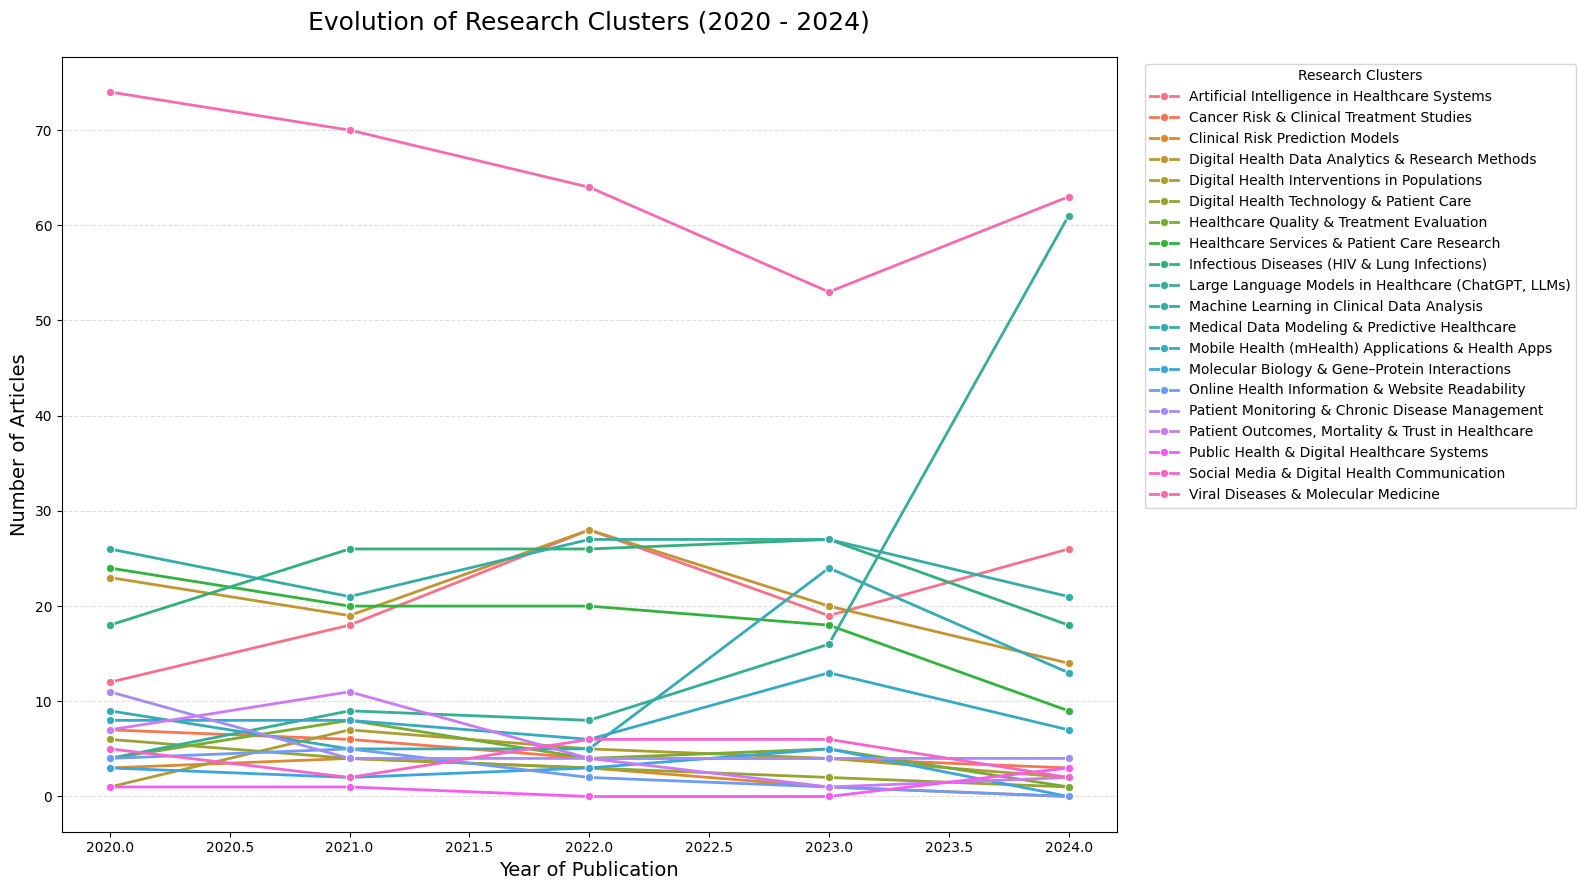


Recent Cluster Activity (2020–2024):
pub_year                                            2020  2021  2022  2023  \
topic_name                                                                   
Artificial Intelligence in Healthcare Systems         12    18    28    19   
Cancer Risk & Clinical Treatment Studies               7     6     4     4   
Clinical Risk Prediction Models                        3     4     3     1   
Digital Health Data Analytics & Research Methods      23    19    28    20   
Digital Health Interventions in Populations            1     7     5     4   
Digital Health Technology & Patient Care               6     4     3     2   
Healthcare Quality & Treatment Evaluation              4     8     4     5   
Healthcare Services & Patient Care Research           24    20    20    18   
Infectious Diseases (HIV & Lung Infections)           18    26    26    27   
Large Language Models in Healthcare (ChatGPT, L...     4     9     8    16   
Machine Learning in Clinic

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the Topic Name Map based on your output
topic_names = {
    0: "Digital Health Technology & Patient Care",
    1: "Molecular Biology & Gene–Protein Interactions",
    2: "Patient Outcomes, Mortality & Trust in Healthcare",
    3: "Clinical Risk Prediction Models",
    4: "Public Health & Digital Healthcare Systems",
    5: "Infectious Diseases (HIV & Lung Infections)",
    6: "Social Media & Digital Health Communication",
    7: "Healthcare Services & Patient Care Research",
    8: "Machine Learning in Clinical Data Analysis",
    9: "Viral Diseases & Molecular Medicine",
    10: "Mobile Health (mHealth) Applications & Health Apps",
    11: "Digital Health Data Analytics & Research Methods",
    12: "Healthcare Quality & Treatment Evaluation",
    13: "Patient Monitoring & Chronic Disease Management",
    14: "Digital Health Interventions in Populations",
    15: "Artificial Intelligence in Healthcare Systems",
    16: "Large Language Models in Healthcare (ChatGPT, LLMs)",
    17: "Online Health Information & Website Readability",
    18: "Cancer Risk & Clinical Treatment Studies",
    19: "Medical Data Modeling & Predictive Healthcare"
}

# 2. Assign Dominant Topic and Name to the DataFrame
def get_dominant_topic(bow):
    probs = lda_model.get_document_topics(bow)
    return sorted(probs, key=lambda x: x[1], reverse=True)[0][0]

df["dominant_topic"] = [
    get_dominant_topic(dictionary.doc2bow(text))
    for text in df["cleaned"]
]

df["topic_name"] = df["dominant_topic"].map(topic_names)

# 3. Create the Year vs Cluster Trend Data
trend_df = df.groupby(["pub_year", "topic_name"]).size().unstack(fill_value=0)

# -------------------------------
# 4. Visualization (ONLY 2022–2024)
# -------------------------------
trend_recent = trend_df.loc[2020:2026]

plt.figure(figsize=(16, 9))
palette = sns.color_palette("husl", len(topic_names))

sns.lineplot(
    data=trend_recent,
    dashes=False,
    marker="o",
    palette=palette,
    linewidth=2
)

plt.title("Evolution of Research Clusters (2020 - 2024)", fontsize=18, pad=20)
plt.xlabel("Year of Publication", fontsize=14)
plt.ylabel("Number of Articles", fontsize=14)

plt.legend(
    title="Research Clusters",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=10
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# -------------------------------
# 5. Recent Cluster Activity Table (2020–2024)
# -------------------------------
print("\nRecent Cluster Activity (2020–2024):")
print(trend_recent.T)

In [12]:
# ========== GENERATE TOPIC NAME FROM TOP WORDS ==========

def generate_topic_name(topic_id, topn=3):
    """
    Create readable topic name using top words.
    Example: 'blockchain + healthcare + security'
    """
    words_probs = lda_model.show_topic(topic_id, topn=topn)
    words = [word.capitalize() for word, _ in words_probs]
    
    return " + ".join(words)


# ========== FORMAT FULL CITATION ==========
def format_citation(row):
    authors = str(row["authors"]).strip()
    year = str(row["pub_year"]).strip()
    title = str(row["title"]).strip()
    journal = str(row["journal"]).strip()
    
    return f"{authors}. ({year}). {title}. {journal}."


# ========== EXPORT STRUCTURED FILE ==========
output_file = "topic_top_articles_with_names.txt"

with open(output_file, "w", encoding="utf-8") as f:

    for topic_id in range(num_topics):
        
        topic_name = generate_topic_name(topic_id)
        
        f.write(f"\n===== {topic_name} =====\n")
        
        top_docs = get_top_docs_for_topic(topic_id, top_n=2)
        
        for _, row in top_docs.iterrows():
            citation = format_citation(row)
            f.write(citation + "\n")

print(f"\nStructured topic citations exported to {output_file}")


Structured topic citations exported to topic_top_articles_with_names.txt


In [13]:
# ========== EXPORT WITH CUSTOM TOPIC NAMES ==========

def format_citation(row):
    authors = str(row["authors"]).strip()
    year = str(row["pub_year"]).strip()
    title = str(row["title"]).strip()
    journal = str(row["journal"]).strip()
    
    return f"{authors}. ({year}). {title}. {journal}."

output_file = "Recent_Cluster_Activity_2024_2026.txt"

with open(output_file, "w", encoding="utf-8") as f:
    
    f.write("Recent Cluster Activity (2024-2026)\n")
    f.write("=====================================\n\n")

    for topic_id in range(num_topics):
        
        topic_label = topic_names.get(topic_id, f"Topic {topic_id}")
        
        f.write(f"\n===== {topic_label} =====\n")
        
        top_docs = get_top_docs_for_topic(topic_id, top_n=2)
        
        for _, row in top_docs.iterrows():
            citation = format_citation(row)
            f.write(citation + "\n")

print(f"\nFile exported successfully: {output_file}")


File exported successfully: Recent_Cluster_Activity_2024_2026.txt


In [14]:
print("Total number of articles:", len(df))

# -----------------------------
# CLEAN + SPLIT KEYWORDS
# -----------------------------

def split_keywords(cell):
    """
    Handles things like:
    "precision, blockchain, digital, twins, trust"
    or "precision | blockchain | digital twins"
    and returns:
    ["precision", "blockchain", "digital", "twins", "trust"]
    """
    if pd.isna(cell):
        return []
    
    text = str(cell).lower()
    
    # Normalize separators: treat '|' as ','
    text = text.replace("|", ",")
    
    parts = [p.strip() for p in text.split(",")]
    parts = [p for p in parts if p]  # remove empty
    
    return parts

# Apply to the ONLY keyword column
df["author_kw_list"] = df["keywords"].apply(split_keywords)

# -----------------------------
# COUNT INDIVIDUAL KEYWORDS
# -----------------------------

keyword_counter = Counter()

for kw_list in df["author_kw_list"]:
    keyword_counter.update(kw_list)

# -----------------------------
# BUILD FINAL TABLE: ONE KEYWORD PER ROW
# -----------------------------

keyword_freq_df = pd.DataFrame(
    keyword_counter.items(),
    columns=["keyword", "frequency"]
).sort_values("frequency", ascending=False)

print("\nTop 20 most frequent individual keywords:")
print(keyword_freq_df.head(20))

# -----------------------------
# SAVE TO CSV
# -----------------------------

keyword_freq_df.to_csv("keyword_frequency.csv", index=False)

print("\nSaved keyword frequencies to: keyword_frequency.csv")

Total number of articles: 1250

Top 20 most frequent individual keywords:
                    keyword  frequency
8          computer science       1024
1               health care        683
9                  medicine        620
41        political science        526
10  artificial intelligence        517
42                      law        502
32               psychology        502
17                economics        376
16          economic growth        338
26             data science        311
22     knowledge management        262
12        computer security        260
73              engineering        239
48                 business        227
54                pathology        224
39           world wide web        216
11                  nursing        211
14         operating system        188
36                 pedagogy        182
67                  biology        181

Saved keyword frequencies to: keyword_frequency.csv


Graph built: 379 nodes, 11381 edges


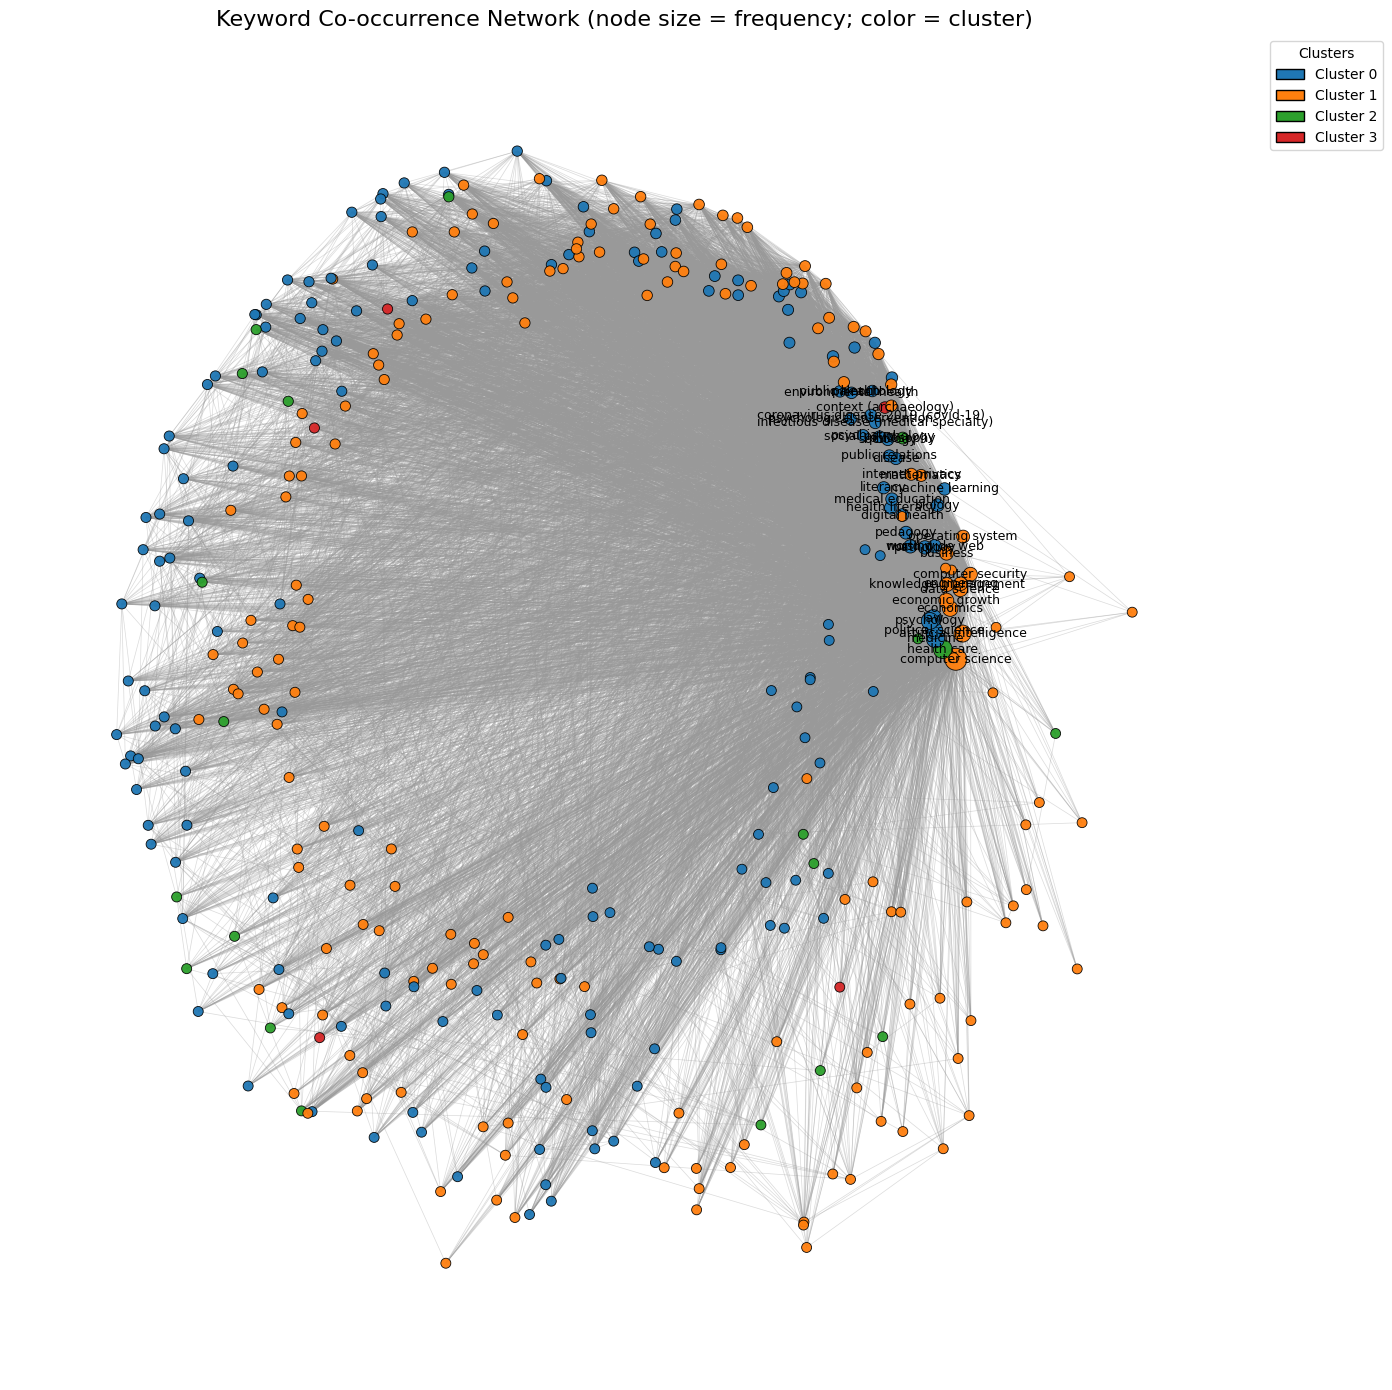

In [15]:
#----------------------Phase 2---------------------------------
# Keywords co-occurrence network (no external community package)
import pandas as pd
import numpy as np
from collections import Counter
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- PARAMETERS ----------------
MIN_KEYWORD_FREQ = 5       # drop keywords with frequency < this
MIN_EDGE_WEIGHT = 2        # drop co-occurrence edges with weight < this
TOP_LABEL_N = 40           # how many top keywords to label
FIGSIZE = (14, 14)
SEED = 42

# ---------------- PREP: expects df["author_kw_list"] to exist ----------------
# If not present, create it using your split_keywords function:
# df["author_kw_list"] = df["keywords"].apply(split_keywords)

kw_lists = df["author_kw_list"].dropna().tolist()

# count keyword frequencies
kw_counter = Counter()
for kws in kw_lists:
    kw_counter.update(kws)

# filter low-frequency keywords
valid_keywords = {k for k, v in kw_counter.items() if v >= MIN_KEYWORD_FREQ}

# build co-occurrence counts (unordered pairs, deduplicated per document)
cooc = Counter()
for kws in kw_lists:
    kws_filtered = [k for k in kws if k in valid_keywords]
    kws_unique = sorted(set(kws_filtered))
    for a, b in itertools.combinations(kws_unique, 2):
        cooc[(a, b)] += 1

# build edges DataFrame and filter by weight
edges_df = pd.DataFrame(
    [(a, b, w) for (a, b), w in cooc.items() if w >= MIN_EDGE_WEIGHT],
    columns=["kw_a", "kw_b", "weight"]
).sort_values("weight", ascending=False).reset_index(drop=True)

# build frequency DataFrame for nodes
freq_df = pd.DataFrame(list(kw_counter.items()), columns=["keyword", "frequency"])
freq_df = freq_df[freq_df["keyword"].isin(valid_keywords)].sort_values("frequency", ascending=False)

# ---------------- BUILD GRAPH ----------------
G = nx.Graph()
for _, r in freq_df.iterrows():
    G.add_node(r["keyword"], frequency=int(r["frequency"]))
for _, r in edges_df.iterrows():
    if r["kw_a"] in G.nodes and r["kw_b"] in G.nodes:
        G.add_edge(r["kw_a"], r["kw_b"], weight=int(r["weight"]))

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ---------------- COMMUNITY DETECTION (networkx built-in) ----------------
# Use greedy modularity communities (no external dependency)
from networkx.algorithms import community as nx_comm

communities = list(nx_comm.greedy_modularity_communities(G))
# convert to partition dict: node -> cluster_id
partition = {}
for cid, comm in enumerate(communities):
    for node in comm:
        partition[node] = cid

nx.set_node_attributes(G, partition, "cluster")
clusters = sorted(set(partition.values()))

# color map for clusters
palette = sns.color_palette("tab10", n_colors=max(10, len(clusters)))
cluster_colors = {c: palette[i % len(palette)] for i, c in enumerate(clusters)}
node_color_list = [cluster_colors[partition[n]] for n in G.nodes()]

# ---------------- LAYOUT ----------------
spring_pos = nx.spring_layout(G, seed=SEED, k=None, iterations=200)
nodes = list(G.nodes())
angle = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
circle_pos = {n: (np.cos(a), np.sin(a)) for n, a in zip(nodes, angle)}
pos = {n: 0.35 * np.array(spring_pos[n]) + 0.65 * np.array(circle_pos[n]) for n in nodes}

# ---------------- DRAW ----------------
plt.figure(figsize=FIGSIZE)
edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges()]) if G.number_of_edges() > 0 else np.array([])
edge_widths = (0.5 + 3.0 * (edge_weights / edge_weights.max())) if edge_weights.size else 0.5

freqs = np.array([G.nodes[n]["frequency"] for n in G.nodes()])
node_sizes = 200 * (freqs / freqs.max()) + 50

nx.draw_networkx_edges(G, pos, alpha=0.35, width=edge_widths, edge_color="#999999")
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_color_list,
    linewidths=0.6,
    edgecolors="black",
    alpha=0.95
)

top_labels = set(freq_df.head(TOP_LABEL_N)["keyword"].tolist())
labels = {n: n for n in G.nodes() if n in top_labels}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_family="sans-serif")

plt.title("Keyword Co-occurrence Network (node size = frequency; color = cluster)", fontsize=16)
plt.axis("off")

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=cluster_colors[c], edgecolor="k", label=f"Cluster {c}") for c in clusters]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc="upper left", title="Clusters")

plt.tight_layout()
plt.show()

# ---------------- EXPORTS ----------------
nx.write_gexf(G, "keyword_cooccurrence_network.gexf")
edges_df.to_csv("keyword_cooccurrence_edges.csv", index=False)
freq_df.to_csv("keyword_frequencies_filtered.csv", index=False)
cluster_df = pd.DataFrame([{"keyword": n, "frequency": G.nodes[n]["frequency"], "cluster": partition[n]} for n in G.nodes()])
cluster_df.to_csv("keyword_clusters.csv", index=False)

SMALL Graph: 40 nodes, 606 edges


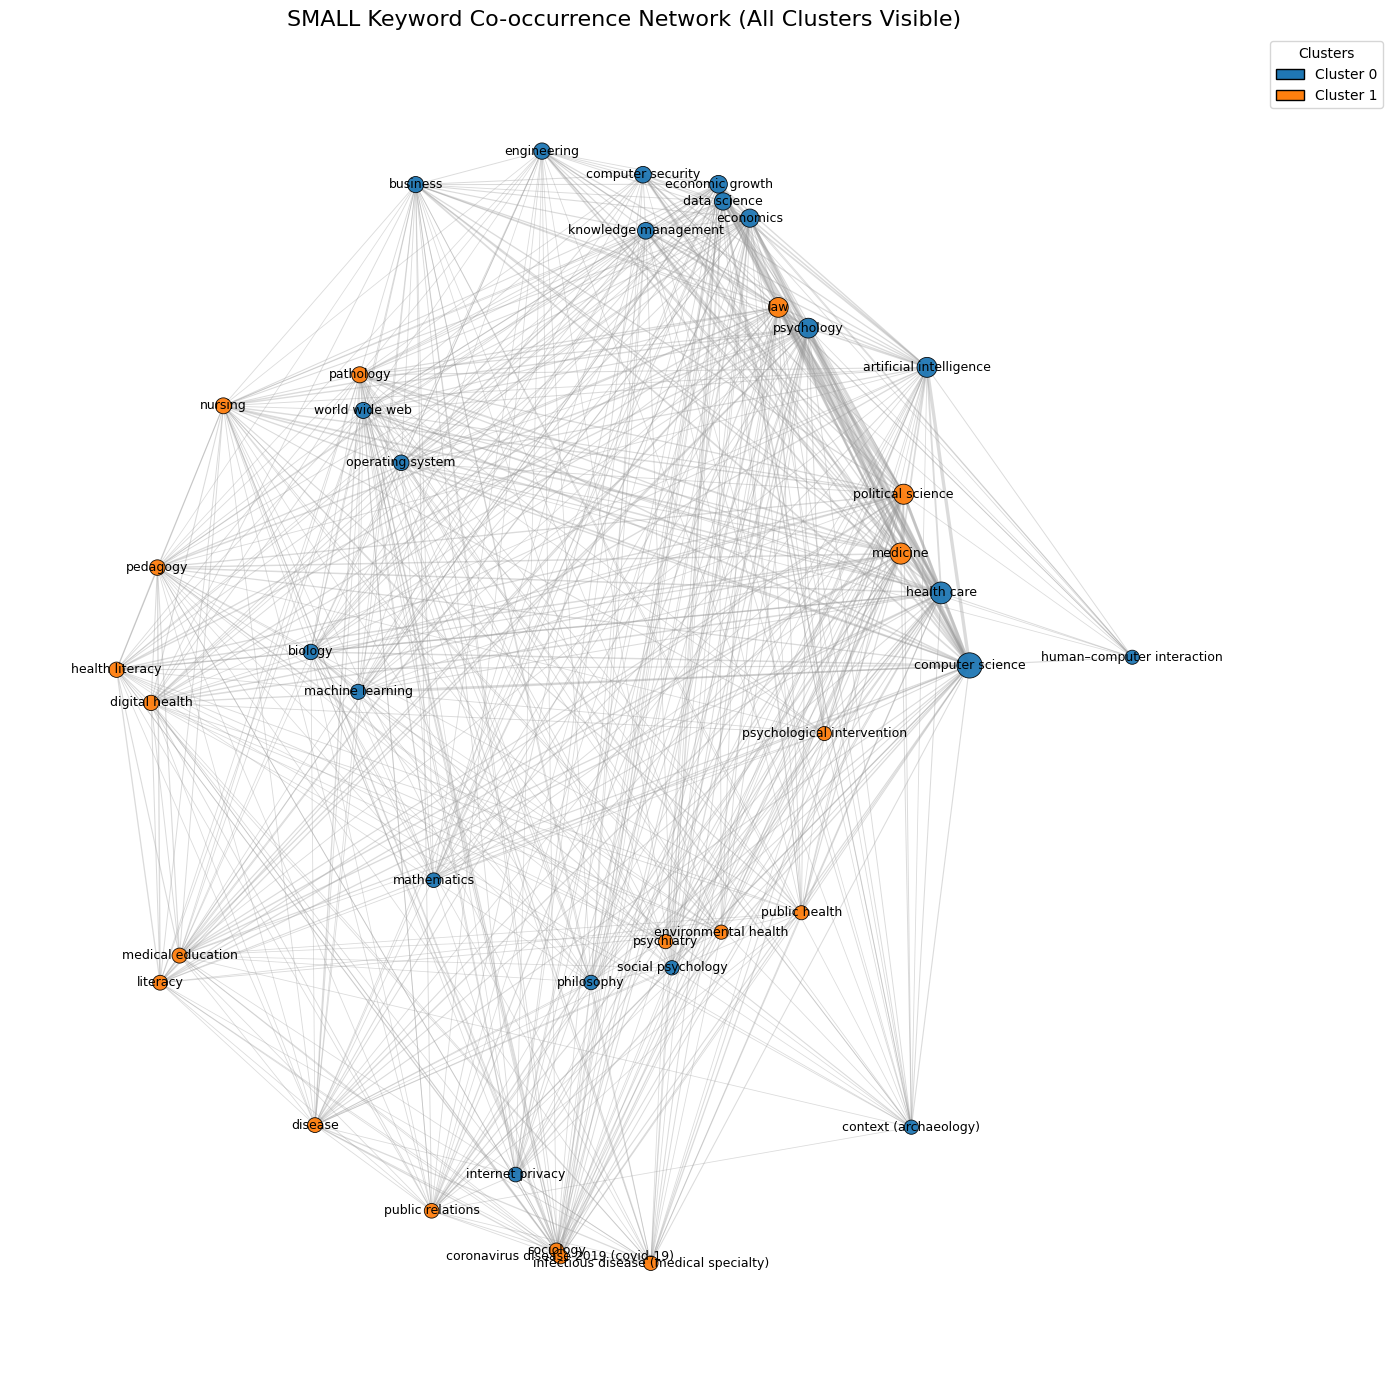

In [16]:
#----------------------Phase 2 (SMALL VERSION)---------------------------------
# Keywords co-occurrence network (small, readable version)

import pandas as pd
import numpy as np
from collections import Counter
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- PARAMETERS ----------------
TOP_KEYWORDS = 40          # <<< REDUCE DATASET HERE
MIN_EDGE_WEIGHT = 15        # keep even weak edges for visibility
TOP_LABEL_N = 40           # label all nodes
FIGSIZE = (14, 14)
SEED = 42

# ---------------- PREP ----------------
kw_lists = df["author_kw_list"].dropna().tolist()

# keyword frequencies
kw_counter = Counter()
for kws in kw_lists:
    kw_counter.update(kws)

# keep only top N keywords
top_keywords = set([kw for kw, _ in kw_counter.most_common(TOP_KEYWORDS)])

# co-occurrence only among top keywords
cooc = Counter()
for kws in kw_lists:
    kws_filtered = [k for k in kws if k in top_keywords]
    kws_unique = sorted(set(kws_filtered))
    for a, b in itertools.combinations(kws_unique, 2):
        cooc[(a, b)] += 1

# edges
edges_df = pd.DataFrame(
    [(a, b, w) for (a, b), w in cooc.items() if w >= MIN_EDGE_WEIGHT],
    columns=["kw_a", "kw_b", "weight"]
)

# node frequencies
freq_df = pd.DataFrame(
    [(kw, freq_counter) for kw, freq_counter in kw_counter.items() if kw in top_keywords],
    columns=["keyword", "frequency"]
).sort_values("frequency", ascending=False)

# ---------------- BUILD GRAPH ----------------
G = nx.Graph()
for _, r in freq_df.iterrows():
    G.add_node(r["keyword"], frequency=int(r["frequency"]))

for _, r in edges_df.iterrows():
    G.add_edge(r["kw_a"], r["kw_b"], weight=int(r["weight"]))

print(f"SMALL Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ---------------- COMMUNITY DETECTION ----------------
from networkx.algorithms import community as nx_comm
communities = list(nx_comm.greedy_modularity_communities(G))

partition = {}
for cid, comm in enumerate(communities):
    for node in comm:
        partition[node] = cid

nx.set_node_attributes(G, partition, "cluster")
clusters = sorted(set(partition.values()))

# color map
palette = sns.color_palette("tab10", n_colors=max(10, len(clusters)))
cluster_colors = {c: palette[i % len(palette)] for i, c in enumerate(clusters)}
node_color_list = [cluster_colors[partition[n]] for n in G.nodes()]

# ---------------- LAYOUT ----------------
spring_pos = nx.spring_layout(G, seed=SEED, k=0.8, iterations=200)
nodes = list(G.nodes())
angle = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
circle_pos = {n: (np.cos(a), np.sin(a)) for n, a in zip(nodes, angle)}

# blend circular + spring layout
pos = {n: 0.35 * np.array(spring_pos[n]) + 0.65 * np.array(circle_pos[n]) for n in nodes}

# ---------------- DRAW ----------------
plt.figure(figsize=FIGSIZE)

edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
edge_widths = 0.5 + 2.0 * (edge_weights / edge_weights.max())

freqs = np.array([G.nodes[n]["frequency"] for n in G.nodes()])
node_sizes = 250 * (freqs / freqs.max()) + 80

nx.draw_networkx_edges(G, pos, alpha=0.35, width=edge_widths, edge_color="#999999")

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_color_list,
    linewidths=0.6,
    edgecolors="black",
    alpha=0.95
)

labels = {n: n for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

plt.title("SMALL Keyword Co-occurrence Network (All Clusters Visible)", fontsize=16)
plt.axis("off")

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=cluster_colors[c], edgecolor="k", label=f"Cluster {c}") for c in clusters]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc="upper left", title="Clusters")

plt.tight_layout()
plt.show()

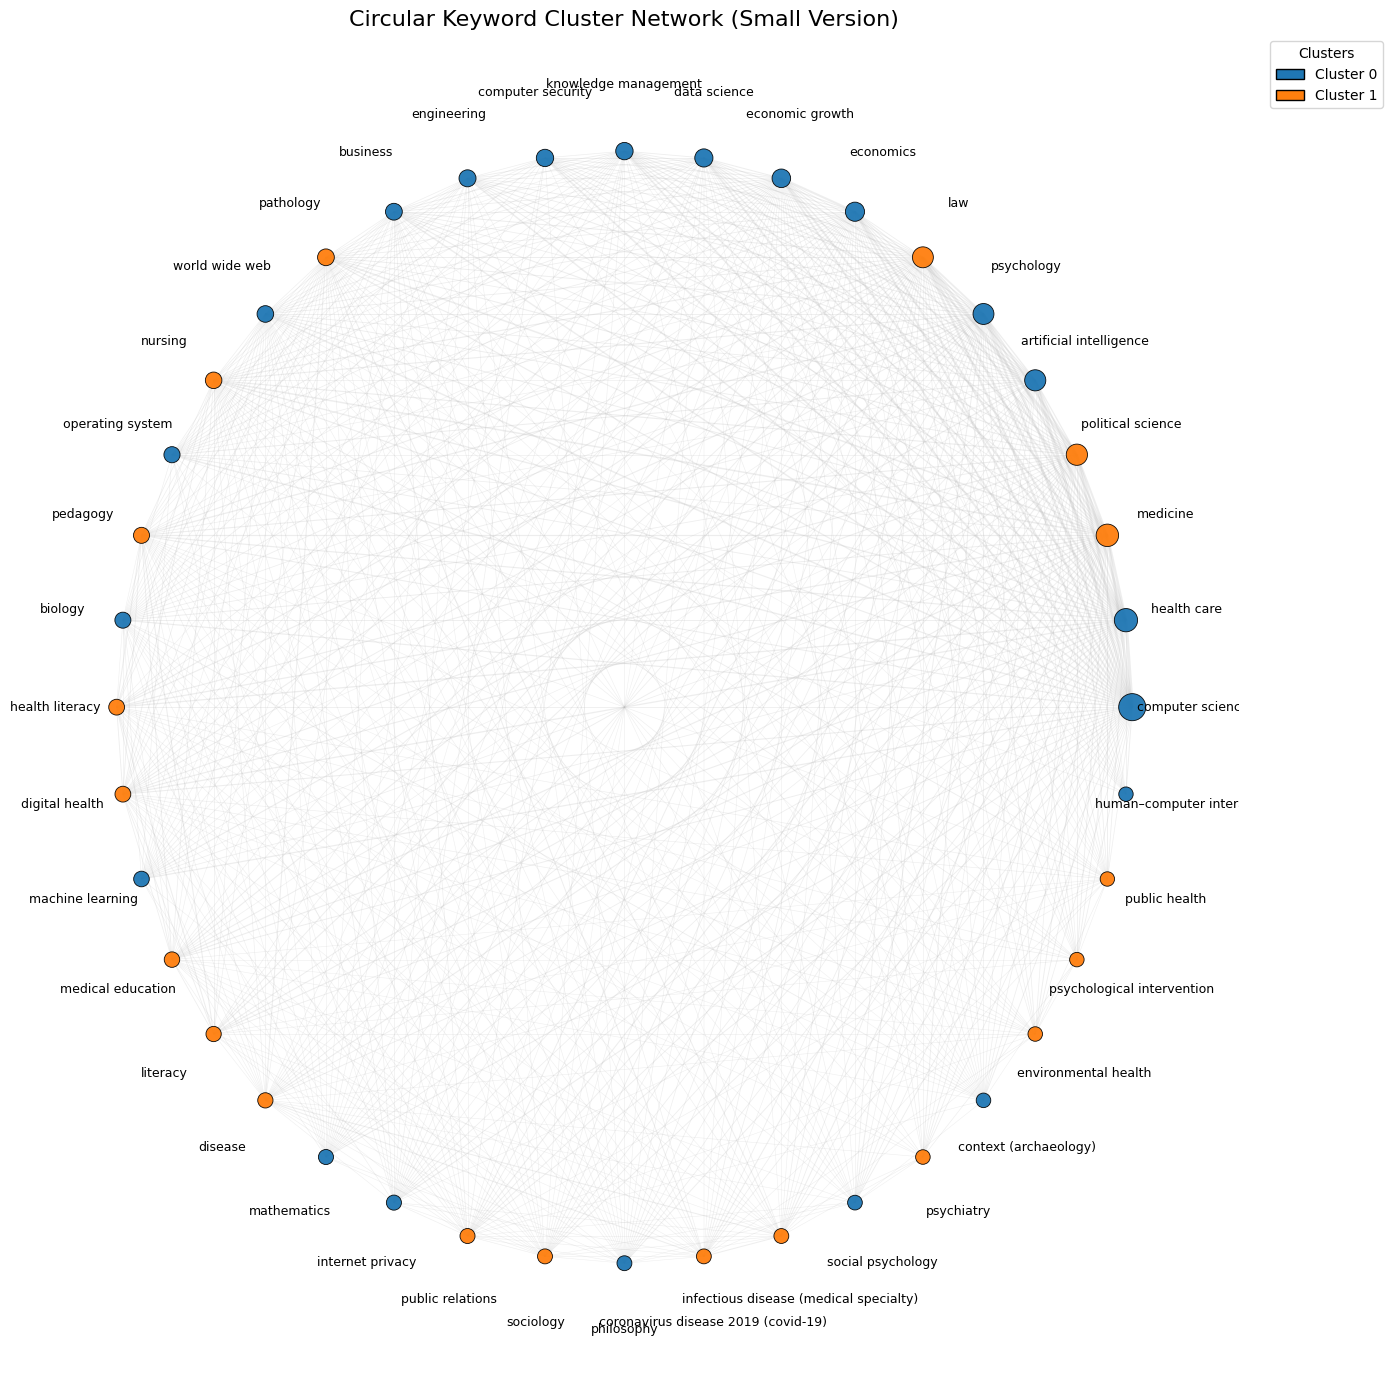

In [17]:
#---------------------- PERFECT CIRCULAR NETWORK ----------------------

plt.figure(figsize=FIGSIZE)

# --- PURE circular layout ---
nodes = list(G.nodes())
N = len(nodes)
angles = np.linspace(0, 2*np.pi, N, endpoint=False)

pos = {
    n: (np.cos(a), np.sin(a))
    for n, a in zip(nodes, angles)
}

# --- EDGE widths ---
edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
edge_widths = 0.3 + 2.0 * (edge_weights / edge_weights.max())

# --- NODE sizes ---
freqs = np.array([G.nodes[n]["frequency"] for n in G.nodes()])
node_sizes = 300 * (freqs / freqs.max()) + 80

# --- DRAW edges ---
nx.draw_networkx_edges(
    G, pos,
    alpha=0.25,
    width=edge_widths,
    edge_color="#bbbbbb"
)

# --- DRAW nodes ---
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_color_list,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.95
)

# --- DRAW LABELS (radial placement) ---
label_pos = {}
for (n, a) in zip(nodes, angles):
    # push labels slightly outward
    label_pos[n] = (1.12*np.cos(a), 1.12*np.sin(a))

nx.draw_networkx_labels(
    G, label_pos,
    font_size=9,
    font_family="sans-serif"
)

# --- LEGEND ---
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=cluster_colors[c], edgecolor="k", label=f"Cluster {c}")
    for c in clusters
]

plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Clusters"
)

plt.title("Circular Keyword Cluster Network (Small Version)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
# ---------------- PERFECT MATCH LAYOUT ----------------
# 1. Pure circular ring for all nodes
nodes = list(G.nodes())
angle = np.linspace(0, 2*np.pi, len(nodes), endpoint=False)
circle_pos = {n: np.array([np.cos(a), np.sin(a)]) for n, a in zip(nodes, angle)}

# 2. Spring layout ONLY for top-frequency nodes (inner core)
core_nodes = set(freq_df.head(TOP_LABEL_N)["keyword"])
core_subgraph = G.subgraph(core_nodes)

core_pos = nx.spring_layout(
    core_subgraph,
    seed=SEED,
    k=0.15,
    iterations=400,
)

# 3. Blend: core nodes move inward, others stay on ring
pos = {}
for n in nodes:
    if n in core_nodes:
        pos[n] = 0.35 * core_pos[n]   # pull inward
    else:
        pos[n] = 1.0 * circle_pos[n]  # stay on ring

In [20]:
import pandas as pd
import numpy as np
from collections import Counter
import itertools
import plotly.graph_objects as go
import seaborn as sns

# ---------------------------------------------------------
# 1. Use the SAME keyword list you used for the co-occurrence graph
# ---------------------------------------------------------
kw_lists = df["author_kw_list"].dropna().tolist()

# ---------------------------------------------------------
# 2. Build keyword co-occurrence pairs
# ---------------------------------------------------------
pair_counter = Counter()

for kws in kw_lists:
    kws_unique = sorted(set(kws))
    for a, b in itertools.combinations(kws_unique, 2):
        pair_counter[(a, b)] += 1

pairs_df = pd.DataFrame(
    [(a, b, w) for (a, b), w in pair_counter.items()],
    columns=["term1", "term2", "weight"]
)

# ---------------------------------------------------------
# 3. FILTERING — this is the FIX
# ---------------------------------------------------------
# Keep only strong connections
pairs_df = pairs_df[pairs_df["weight"] >= 3]

# Keep only top N keywords by frequency
freq_counter = Counter()
for kws in kw_lists:
    freq_counter.update(kws)

freq_df = pd.DataFrame(freq_counter.items(), columns=["kw", "freq"])
top_keywords = set(freq_df.sort_values("freq", ascending=False).head(40)["kw"])

pairs_df = pairs_df[
    pairs_df["term1"].isin(top_keywords) &
    pairs_df["term2"].isin(top_keywords)
]

# ---------------------------------------------------------
# 4. Build node list
# ---------------------------------------------------------
all_terms = sorted(set(pairs_df["term1"]).union(set(pairs_df["term2"])))
term_to_id = {t: i for i, t in enumerate(all_terms)}

sources = [term_to_id[t] for t in pairs_df["term1"]]
targets = [term_to_id[t] for t in pairs_df["term2"]]
values  = pairs_df["weight"].tolist()

# ---------------------------------------------------------
# 5. Color palette
# ---------------------------------------------------------
palette = sns.color_palette("tab20", len(all_terms))
node_colors = [
    f"rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, 0.85)"
    for r, g, b in palette
]

# ---------------------------------------------------------
# 6. Build Sankey diagram
# ---------------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=18,
        thickness=18,
        line=dict(color="black", width=0.4),
        label=all_terms,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color="rgba(150,150,150,0.25)"
    )
)])

fig.update_layout(
    title_text="Keyword Flow (Cleaned Sankey Diagram)",
    font_size=12,
    width=1400,
    height=900
)

fig.show()

In [21]:
import pandas as pd
import numpy as np
from collections import Counter
import itertools
import plotly.graph_objects as go
import seaborn as sns

# ---------------------------------------------------------
# 1. Use your existing keyword lists
# ---------------------------------------------------------
kw_lists = df["author_kw_list"].dropna().tolist()

# ---------------------------------------------------------
# 2. Build co-occurrence pairs
# ---------------------------------------------------------
pair_counter = Counter()

for kws in kw_lists:
    kws_unique = sorted(set(kws))
    for a, b in itertools.combinations(kws_unique, 2):
        pair_counter[(a, b)] += 1

pairs_df = pd.DataFrame(
    [(a, b, w) for (a, b), w in pair_counter.items()],
    columns=["term1", "term2", "weight"]
)

# ---------------------------------------------------------
# 3. SMALL SAMPLE FILTER
# ---------------------------------------------------------

# Top 8 most frequent keywords
freq_counter = Counter()
for kws in kw_lists:
    freq_counter.update(kws)

freq_df = pd.DataFrame(freq_counter.items(), columns=["kw", "freq"])
top_keywords = set(freq_df.sort_values("freq", ascending=False).head(8)["kw"])

# Keep only pairs where both terms are in top 8
pairs_df = pairs_df[
    pairs_df["term1"].isin(top_keywords) &
    pairs_df["term2"].isin(top_keywords)
]

# Keep only strong connections
pairs_df = pairs_df[pairs_df["weight"] >= 2]

print("Small sample pairs:")
print(pairs_df)

# ---------------------------------------------------------
# 4. Build node list
# ---------------------------------------------------------
all_terms = sorted(set(pairs_df["term1"]).union(set(pairs_df["term2"])))
term_to_id = {t: i for i, t in enumerate(all_terms)}

sources = [term_to_id[t] for t in pairs_df["term1"]]
targets = [term_to_id[t] for t in pairs_df["term2"]]
values  = pairs_df["weight"].tolist()

# ---------------------------------------------------------
# 5. Colors
# ---------------------------------------------------------
palette = sns.color_palette("tab10", len(all_terms))
node_colors = [
    f"rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, 0.85)"
    for r, g, b in palette
]

# ---------------------------------------------------------
# 6. Build Sankey
# ---------------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_terms,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color="rgba(150,150,150,0.3)"
    )
)])

fig.update_layout(
    title_text="Small Sample Sankey (Top 8 Keywords)",
    font_size=12,
    width=1000,
    height=600
)

fig.show()

Small sample pairs:
                        term1              term2  weight
0     artificial intelligence   computer science     517
5     artificial intelligence          economics     160
7     artificial intelligence        health care     229
9     artificial intelligence           medicine     199
21           computer science          economics     311
23           computer science        health care     544
25           computer science           medicine     433
88                  economics        health care     329
90                  economics           medicine     199
109               health care           medicine     416
313          computer science         psychology     361
381                 economics         psychology     130
388               health care         psychology     332
413                  medicine         psychology     323
426   artificial intelligence                law     149
428   artificial intelligence  political science     155
429   artif

In [22]:
import pandas as pd
import numpy as np
from collections import Counter
import itertools
import plotly.graph_objects as go
import seaborn as sns

# ---------------------------------------------------------
# 1. Load keyword lists
# ---------------------------------------------------------
kw_lists = df["author_kw_list"].dropna().tolist()

# ---------------------------------------------------------
# 2. Count keyword frequencies
# ---------------------------------------------------------
freq_counter = Counter()
for kws in kw_lists:
    freq_counter.update(kws)

freq_df = pd.DataFrame(freq_counter.items(), columns=["kw", "freq"])
freq_df = freq_df.sort_values("freq", ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
# 3. Split into Term1, Term3, Term2 (top 45 keywords)
# ---------------------------------------------------------
top45 = freq_df.head(45)["kw"].tolist()

Term1 = top45[0:15]
Term3 = top45[15:30]
Term2 = top45[30:45]

# ---------------------------------------------------------
# 4. Build co-occurrence pairs
# ---------------------------------------------------------
pair_counter = Counter()

for kws in kw_lists:
    kws_unique = sorted(set(kws))
    for a, b in itertools.combinations(kws_unique, 2):
        pair_counter[(a, b)] += 1

pairs_df = pd.DataFrame(
    [(a, b, w) for (a, b), w in pair_counter.items()],
    columns=["term1", "term2", "weight"]
)

# ---------------------------------------------------------
# 5. Build flows Term1 → Term3
# ---------------------------------------------------------
flows_13 = pairs_df[
    pairs_df["term1"].isin(Term1) & pairs_df["term2"].isin(Term3)
]

# ---------------------------------------------------------
# 6. Build flows Term3 → Term2
# ---------------------------------------------------------
flows_32 = pairs_df[
    pairs_df["term1"].isin(Term3) & pairs_df["term2"].isin(Term2)
]

# ---------------------------------------------------------
# 7. Build node list
# ---------------------------------------------------------
all_nodes = Term1 + Term3 + Term2
node_to_id = {n: i for i, n in enumerate(all_nodes)}

# ---------------------------------------------------------
# 8. Build Sankey links
# ---------------------------------------------------------
sources = []
targets = []
values = []

# Term1 → Term3
for _, r in flows_13.iterrows():
    sources.append(node_to_id[r["term1"]])
    targets.append(node_to_id[r["term2"]])
    values.append(r["weight"])

# Term3 → Term2
for _, r in flows_32.iterrows():
    sources.append(node_to_id[r["term1"]])
    targets.append(node_to_id[r["term2"]])
    values.append(r["weight"])

# ---------------------------------------------------------
# 9. Colors
# ---------------------------------------------------------
palette = sns.color_palette("tab20", len(all_nodes))
node_colors = [
    f"rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, 0.85)"
    for r, g, b in palette
]

# ---------------------------------------------------------
# 10. Build Alluvial Diagram
# ---------------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color="rgba(150,150,150,0.25)"
    )
)])

fig.update_layout(
    title_text="Three‑Column Alluvial Diagram (Top 45 Keywords)",
    font_size=12,
    width=1500,
    height=900
)

fig.show()

In [23]:
# 1. Add a Retrieval Layer (TF‑IDF + Cosine Similarity
# This lets your notebook answer user queries

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Join cleaned tokens back into text
df["cleaned_text"] = df["cleaned"].apply(lambda x: " ".join(x))

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df["cleaned_text"])

def search_papers(query, top_n=15):
    query_clean = " ".join(clean_text(query))
    q_vec = vectorizer.transform([query_clean])
    sims = cosine_similarity(q_vec, tfidf_matrix).flatten()
    
    df_temp = df.copy()
    df_temp["similarity"] = sims
    return df_temp.sort_values("similarity", ascending=False).head(top_n)

In [24]:
results = search_papers("digital health apps for chronic disease")
results[["title", "similarity", "topic_name"]]

,title,similarity,topic_name
322,MedMetaverse: Medical Care of Chronic Disease ...,0.326781,Cancer Risk & Clinical Treatment Studies
691,Understanding the digital health care experien...,0.307380,Artificial Intelligence in Healthcare Systems
1048,Precision medicine in the era of artificial in...,0.274193,Patient Monitoring & Chronic Disease Management
20,Digital Health Literacy and Its Association Wi...,0.257641,Machine Learning in Clinical Data Analysis
1062,"Trust Me, I’m a Doctor – User Perceptions of A...",0.255837,Infectious Diseases (HIV & Lung Infections)
478,The need for a new generation of digital menta...,0.242675,Machine Learning in Clinical Data Analysis
1123,Artificial Intelligence-Based Conversational A...,0.233021,Social Media & Digital Health Communication
90,The application of artificial intelligence in ...,0.230992,Infectious Diseases (HIV & Lung Infections)
251,Improving health literacy using the power of d...,0.224466,Mobile Health (mHealth) Applications & Health ...
745,Selected health behaviors associated with heal...,0.221261,Artificial Intelligence in Healthcare Systems


In [25]:
# Enrich Retrieved Results with Topic Modeling Context
# This attaches:
# - dominant topic
# - topic name
# - top words of that topic
# - keywords

def get_topic_top_words(topic_id, topn=10):
    return [w for w, _ in lda_model.show_topic(topic_id, topn=topn)]

def enrich_with_topic_info(df_subset):
    rows = []
    for _, row in df_subset.iterrows():
        topic_id = row["dominant_topic"]
        topic_label = topic_names.get(topic_id, f"Topic {topic_id}")
        top_words = get_topic_top_words(topic_id, topn=10)
        
        rows.append({
            "title": row["title"],
            "authors": row["authors"],
            "pub_year": row["pub_year"],
            "journal": row["journal"],
            "similarity": row["similarity"],
            "topic_id": topic_id,
            "topic_name": topic_label,
            "topic_top_words": ", ".join(top_words),
            "keywords": row.get("keywords", "")
        })
    return pd.DataFrame(rows)

In [26]:
enriched = enrich_with_topic_info(results)
enriched.head()

,title,authors,pub_year,journal,similarity,topic_id,topic_name,topic_top_words,keywords
0,MedMetaverse: Medical Care of Chronic Disease ...,"Dileep Kumar Murala, Sandeep Kumar Panda, Suja...",2023,IEEE Access,0.326781,18,Cancer Risk & Clinical Treatment Studies,"data, system, privacy, security, patient, bloc...","Wearable computer, Computer science, Variety (..."
1,Understanding the digital health care experien...,"Na-Young Park, Nan‐He Yoon, Nam Soo Park, Youn...",2022,Korean Journal of Health Education and Promotion,0.307380,15,Artificial Intelligence in Healthcare Systems,"literacy, digital, study, student, education, ...","eHealth, Health literacy, Health care, Literac..."
2,Precision medicine in the era of artificial in...,"Murugan Subramanian, Anne Wojtusciszyn, Lucie ...",2020,Journal of Translational Medicine,0.274193,13,Patient Monitoring & Chronic Disease Management,"mental, human, interaction, social, service, j...","Disease, Life expectancy, Medicine, Exposome, ..."
3,Digital Health Literacy and Its Association Wi...,"Eva Yuen, Natalie Winter, Feby Savira, Catheri...",2024,Interactive Journal of Medical Research,0.257641,8,Machine Learning in Clinical Data Analysis,"digital, care, technology, trust, tool, need, ...","Health literacy, Literacy, Digital health, Ass..."
4,"Trust Me, I’m a Doctor – User Perceptions of A...","Matthias Baldauf, Peter Fröehlich, Rainer Endl",2020,Unknown Source,0.255837,5,Infectious Diseases (HIV & Lung Infections),"healthcare, model, decision, intelligence, lea...","Mobile apps, Computer science, Perception, Int..."


In [27]:
# Topic‑wise Breakdown for the Query
# This shows:
# - top topics appearing in the retrieved set
# - their top words
# - top articles within those topics
def top_articles_per_topic_in_results(results_df, top_n_topics=3, top_n_articles=3):
    topic_counts = results_df["dominant_topic"].value_counts().head(top_n_topics).index
    
    out = {}
    for t in topic_counts:
        topic_label = topic_names.get(t, f"Topic {t}")
        top_words = get_topic_top_words(t, topn=10)
        
        subset = results_df[results_df["dominant_topic"] == t]
        subset = subset.sort_values("similarity", ascending=False).head(top_n_articles)
        
        out[t] = {
            "topic_name": topic_label,
            "top_words": top_words,
            "top_articles": subset[["title", "authors", "pub_year", "journal", "similarity"]]
        }
    return out

In [28]:
topic_view = top_articles_per_topic_in_results(results)
topic_view

{8: {'topic_name': 'Machine Learning in Clinical Data Analysis',
  'top_words': ['digital',
   'care',
   'technology',
   'trust',
   'tool',
   'need',
   'clinical',
   'literacy',
   'use',
   'approach'],
  'top_articles':                                                  title  \
  20   Digital Health Literacy and Its Association Wi...   
  478  The need for a new generation of digital menta...   
  795  Digital Technologies and Data Science as Healt...   
  
                                                 authors  pub_year  \
  20   Eva Yuen, Natalie Winter, Feby Savira, Catheri...      2024   
  478     John Torous, Keris Jän Myrick, Adrián Aguilera      2023   
  795                                   João V. Cordeiro      2021   
  
                                       journal  similarity  
  20   Interactive Journal of Medical Research    0.257641  
  478                         World Psychiatry    0.242675  
  795                    Frontiers in Medicine    0.217185  },
 5

In [29]:
#Build Keyword Co‑Occurrence Network (for visualization)
# This produces a network you can load into Gephi, Cytoscape, or NetworkX visualizations.
import itertools
import networkx as nx

def build_keyword_cooccurrence(df, min_freq=3):
    G = nx.Graph()
    
    for kw_list in df["author_kw_list"]:
        kws = [k for k in kw_list if k]
        for a, b in itertools.combinations(sorted(set(kws)), 2):
            if G.has_edge(a, b):
                G[a][b]["weight"] += 1
            else:
                G.add_edge(a, b, weight=1)
    
    # Filter weak edges
    edges_to_remove = [(u, v) for u, v, d in G.edges(data=True) if d["weight"] < min_freq]
    G.remove_edges_from(edges_to_remove)
    
    return G

keyword_graph = build_keyword_cooccurrence(df, min_freq=3)

In [30]:
edges_df = nx.to_pandas_edgelist(keyword_graph)
edges_df.to_csv("keyword_network_edges.csv", index=False)

In [31]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Jasraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Jasraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [32]:
import re

def split_sentences_fast(text):
    # Split on ., ?, ! but keep punctuation
    parts = re.split(r'(?<=[.!?])\s+', text)
    return [p.strip() for p in parts if p.strip()]

In [33]:
CONTRIB_PATTERNS = [
    r"\bwe propose\b",
    r"\bwe present\b",
    r"\bwe introduce\b",
    r"\bwe develop\b",
    r"\bwe design\b",
    r"\bwe evaluate\b",
    r"\bwe investigate\b",
    r"\bwe examine\b",
    r"\bwe analyze\b",
    r"\bthis paper\b",
    r"\bthis study\b",
    r"\bin this paper\b",
    r"\bin this study\b",
    r"\bthe aim of this\b",
    r"\bthe objective of this\b",
    r"\bthe purpose of this\b"
]

CONTRIB_REGEX = re.compile("|".join(CONTRIB_PATTERNS), re.IGNORECASE)

def extract_what_paper_does(abstract, debug=False):
    if pd.isna(abstract) or not str(abstract).strip():
        return ""
    
    text = str(abstract).strip()
    text = re.sub(r"\s+", " ", text)  # normalize whitespace
    
    # 1. Split into sentences
    sentences = split_sentences_fast(text)
    if debug:
        print("\n--- Sentences ---")
        for s in sentences:
            print(s)
    
    # 2. Pattern-based extraction
    for s in sentences:
        if CONTRIB_REGEX.search(s):
            if debug:
                print("\nMatched:", s)
            return s.strip()
    
    # 3. Fallback: choose the most informative sentence
    def score_sentence(s):
        length_score = len(s.split())
        verb_score = len(re.findall(
            r"\b(is|are|was|were|be|have|has|propose|present|develop|evaluate|investigate)\b",
            s.lower()
        ))
        return length_score + verb_score
    
    best_sentence = max(sentences, key=score_sentence)
    
    if debug:
        print("\nFallback:", best_sentence)
    
    return best_sentence.strip()

In [34]:
df["what_this_paper_does"] = df["abstract"].apply(extract_what_paper_does)

In [35]:
extract_what_paper_does(df["abstract"].iloc[0], debug=True)


--- Sentences ---
Comprehensive clinical documentation is crucial for effective healthcare delivery, yet it poses a significant burden on healthcare professionals, leading to burnout, increased medical errors, and compromised patient safety.
This paper explores the potential of generative AI (Artificial Intelligence) to streamline the clinical documentation process, specifically focusing on generating SOAP (Subjective, Objective, Assessment, Plan) and BIRP (Behavior, Intervention, Response, Plan) notes.
We present a case study demonstrating the application of natural language processing (NLP) and automatic speech recognition (ASR) technologies to transcribe patient-clinician interactions, coupled with advanced prompting techniques to generate draft clinical notes using large language models (LLMs).
The study highlights the benefits of this approach, including time savings, improved documentation quality, and enhanced patient-centered care.
Additionally, we discuss ethical consideratio

'This paper explores the potential of generative AI (Artificial Intelligence) to streamline the clinical documentation process, specifically focusing on generating SOAP (Subjective, Objective, Assessment, Plan) and BIRP (Behavior, Intervention, Response, Plan) notes.'

In [36]:
final_cols = [
    "title",
    "authors",
    "pub_year",
    "journal",
    "keywords",
    "dominant_topic",
    "topic_name",
    "what_this_paper_does"
]

spreadsheet_df = df[final_cols]
spreadsheet_df.to_csv("paper_database_with_contribution.csv", index=False)

In [ ]:
# -----------------------------
# 1. Get LDA topic distribution for a query
# -----------------------------
def get_query_topic(query):
    query_clean = clean_text(query)
    bow = dictionary.doc2bow(query_clean)
    topic_dist = lda_model.get_document_topics(bow)
    return topic_dist


# -----------------------------
# 2. Extract dominant topic from topic distribution
# -----------------------------
def get_dominant_topic(topic_dist):
    if not topic_dist:
        return None
    # topic_dist = [(topic_id, prob), ...]
    return max(topic_dist, key=lambda x: x[1])[0]


# -----------------------------
# 3. Simple Topic-Routed Search
# -----------------------------
def search_by_topic(query, top_n=15):
    topic_dist = get_query_topic(query)
    dom_topic = get_dominant_topic(topic_dist)

    if dom_topic is None:
        print("No dominant topic found for query.")
        return df.head(0)

    # Filter documents belonging to this topic
    results = df[df["dominant_topic"] == dom_topic]

    # Return top N (no TF-IDF ranking)
    return results.head(top_n)


# -----------------------------
# 4. Hybrid Topic-Routed + TF-IDF Ranking (Recommended)
# -----------------------------
from sklearn.metrics.pairwise import cosine_similarity

def topic_routed_search(query, top_n=15):
    # Step 1: Get dominant topic
    topic_dist = get_query_topic(query)
    dom_topic = get_dominant_topic(topic_dist)

    if dom_topic is None:
        print("No dominant topic found for query.")
        return df.head(0)

    # Step 2: Filter docs by topic
    topic_docs = df[df["dominant_topic"] == dom_topic].copy()

    # Step 3: Compute TF-IDF similarity only within this topic
    query_clean = " ".join(clean_text(query))
    q_vec = vectorizer.transform([query_clean])

    # restrict tfidf_matrix to topic_docs index
    sims = cosine_similarity(q_vec, tfidf_matrix[topic_docs.index]).flatten()

    topic_docs["similarity"] = sims

    # Step 4: Sort by similarity
    return topic_docs.sort_values("similarity", ascending=False).head(top_n)


# -----------------------------
# 5. Example Usage
# -----------------------------
query = "digital health apps for chronic disease"
results = topic_routed_search(query)

results[["title", "similarity", "topic_name"]]

,title,similarity,topic_name
691,Understanding the digital health care experien...,0.307380,Artificial Intelligence in Healthcare Systems
745,Selected health behaviors associated with heal...,0.221261,Artificial Intelligence in Healthcare Systems
386,The Effectiveness of Publicly Available Web-Ba...,0.215558,Artificial Intelligence in Healthcare Systems
506,COVID-19 infodemic and digital health literacy...,0.205247,Artificial Intelligence in Healthcare Systems
169,Impact of digital health literacy on public he...,0.201341,Artificial Intelligence in Healthcare Systems
47,The Role of Digital Health Technologies on Mat...,0.190820,Artificial Intelligence in Healthcare Systems
229,Association between digital health literacy an...,0.178342,Artificial Intelligence in Healthcare Systems
290,Digital literacy level and associated factors ...,0.172344,Artificial Intelligence in Healthcare Systems
848,Digital Health Literacy in Bipolar Disorder: I...,0.155461,Artificial Intelligence in Healthcare Systems
501,Digital Health Literacy: Bibliometric Analysis,0.154618,Artificial Intelligence in Healthcare Systems


In [ ]:
# --- Enrich df with topic_name and topic_top_words before saving ---

def get_topic_top_words(topic_id, topn=10):
    return [w for w, _ in lda_model.show_topic(topic_id, topn=topn)]

df["topic_name"] = df["dominant_topic"].apply(
    lambda t: topic_names.get(t, f"Topic {t}")
)

df["topic_top_words"] = df["dominant_topic"].apply(
    lambda t: ", ".join(get_topic_top_words(t))
)

In [ ]:
import joblib

joblib.dump(df, "df.pkl")
joblib.dump(dictionary, "dictionary.pkl")
joblib.dump(lda_model, "lda_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(tfidf_matrix, "tfidf_matrix.pkl")
joblib.dump(clean_text, "clean_text.pkl")